# AutoEIT — Human Final Ratings on Resegmented Hit Recordings

For each of the 102 "hit" recordings in the resegmented set (`data/resegmented_hit_recordings.txt`
— exactly 30 resegmented items each), what score did the student actually get on that EIT
administration, per the human raters? This is independent of ASR entirely; it's a check on what
kind of students/recordings ended up in the "hit" set.

## Source and matching

Each recording has its own per-sentence sheet across the 5 `data/human-transcriptions/*.xlsx`
workbooks (`Sentence`, `Stimulus`, `Transcription Rater 1`, `Score Rater 1`, `Transcription Rater 2`,
`Score Rater 2`, ...). Recording names are matched to sheets with the same
`parse_folder_name`/`parse_sheet_name` helpers `src/postprocessing/build_postprocessed_csv.py`
already uses to merge these sheets into `data/postprocessed/`.

## Scoring rule

Per-sentence score = mean(`Score Rater 1`, `Score Rater 2`); a recording's final rating = sum over
its ~30 sentences (max ~120 on a 0-4-per-item scale). This matches the `EIT1_R1_Score`/
`EIT1_R2_Score` totals in each workbook's `038 EIT Info` summary sheet.

Deliberately **not** used: the `Final Rating` column present in 3 of the 5 workbooks. When the two
raters disagreed (`R1-R2Match?` == 0) and no 3rd rater ever adjudicated — which is most
disagreements in this dataset — that column holds a literal `99999` placeholder rather than a real
score. `Score Rater 1`/`Score Rater 2` are present in every workbook and need no such workaround.

2 of the 102 hit recordings have no rater-2 score at all (genuinely unscored, confirmed in the raw
sheet — not a matching gap) and are excluded below, reported by name.

One point per hit recording: a student whose both EIT1 and EIT2 landed in the hit list contributes
2 points, not 1.


## Config

In [1]:
import glob
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src.postprocessing.build_postprocessed_csv import parse_folder_name, parse_sheet_name


In [2]:
HUMAN_DIR = Path("../../data/human-transcriptions")
MAX_SCORE_PER_ITEM = 4

hit_recordings = sorted(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")


102 hit recordings


## Match hit recordings to their human-rated score

`build_sheet_index` mirrors `load_human_sheets`'s sheet-name parsing and its dedup rule (prefer the
sheet with the most non-empty rater-1 transcriptions when a recording appears in more than one
workbook), but pulls `Score Rater 1`/`Score Rater 2` instead of the transcription text.


In [3]:
def build_sheet_index(human_dir: Path) -> dict[tuple[str, str], list[tuple[str, str, list[float | None], int]]]:
    """(recording_number, version_letter) -> [(file, sheet, per-sentence mean(R1,R2) scores, n non-empty rater1 rows), ...]"""
    index: dict[tuple[str, str], list[tuple[str, str, list[float | None], int]]] = {}
    for path in sorted(human_dir.glob("*.xlsx")):
        import openpyxl

        wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
        for sheet_name in wb.sheetnames:
            key = parse_sheet_name(sheet_name)
            if key is None:
                continue
            ws = wb[sheet_name]
            rows_iter = ws.iter_rows(values_only=True)
            header = [str(h).strip().lower() if h else h for h in next(rows_iter)]

            def col(name):
                return header.index(name) if name in header else None

            r1_score_i = col("score rater 1")
            r2_score_i = col("score rater 2")
            r1_text_i = col("transcription rater 1")

            def get(row, i):
                return row[i] if i is not None and i < len(row) else None

            scores, n_r1_text = [], 0
            for row in rows_iter:
                if get(row, 0) is None:
                    break
                if get(row, r1_text_i):
                    n_r1_text += 1
                r1v, r2v = get(row, r1_score_i), get(row, r2_score_i)
                v = (r1v + r2v) / 2 if isinstance(r1v, (int, float)) and isinstance(r2v, (int, float)) else None
                scores.append(v)
            index.setdefault(key, []).append((path.name, sheet_name, scores, n_r1_text))
        wb.close()
    return index


sheet_index = build_sheet_index(HUMAN_DIR)
print(f"{len(sheet_index)} recording sheets indexed")


232 recording sheets indexed


In [4]:
def resolve_final_ratings(recordings: list[str], index) -> tuple[pd.DataFrame, list[tuple[str, str]]]:
    rows, missing = [], []
    for name in recordings:
        key = parse_folder_name(name)
        candidates = index.get(key) if key else None
        if not candidates:
            missing.append((name, "no matching sheet"))
            continue
        _, _, scores, _ = max(candidates, key=lambda c: c[3])
        n_missing = sum(1 for v in scores if v is None)
        if not scores or n_missing:
            missing.append((name, f"{n_missing}/{len(scores)} sentences unscored"))
            continue
        rows.append({
            "recording": name,
            "recording_number": key[0],
            "version": key[1],
            "n_items": len(scores),
            "final_rating": sum(scores),
        })
    return pd.DataFrame(rows), missing


ratings, missing = resolve_final_ratings(hit_recordings, sheet_index)
print(f"resolved {len(ratings)} of {len(hit_recordings)} hit recordings")
if missing:
    print("excluded:")
    for name, reason in missing:
        print(f"  {name}: {reason}")


resolved 100 of 102 hit recordings
excluded:
  038020_EIT-2A: 30/30 sentences unscored
  038065_EITv-2A: 30/30 sentences unscored


## Summary

In [5]:
summary = pd.Series({
    "n_recordings": len(ratings),
    "n_unique_students": ratings["recording_number"].nunique(),
    "mean": round(ratings["final_rating"].mean(), 2),
    "median": ratings["final_rating"].median(),
    "std": round(ratings["final_rating"].std(), 2),
    "min": ratings["final_rating"].min(),
    "max": ratings["final_rating"].max(),
})
summary


n_recordings         100.00
n_unique_students     64.00
mean                  73.57
median                76.25
std                   27.58
min                    2.50
max                  119.00
dtype: float64

## Distribution

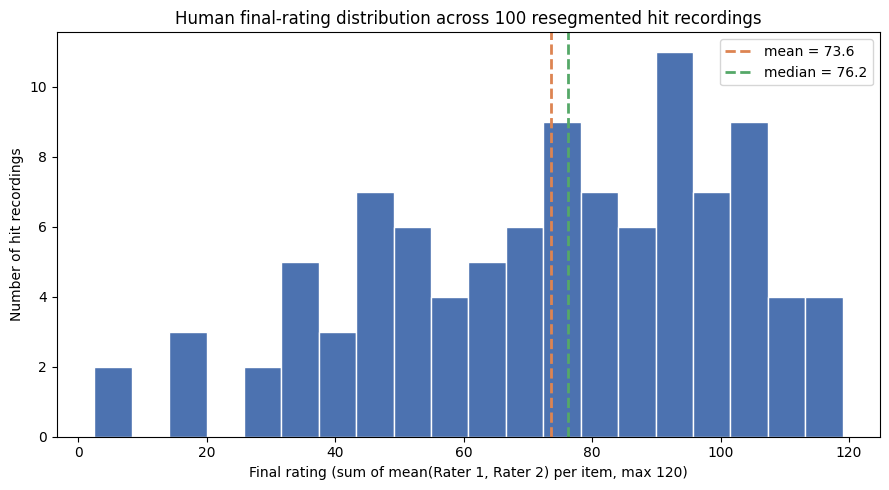

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ratings["final_rating"], bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(ratings["final_rating"].mean(), color="#DD8452", linestyle="--", linewidth=2,
           label=f"mean = {ratings['final_rating'].mean():.1f}")
ax.axvline(ratings["final_rating"].median(), color="#55A868", linestyle="--", linewidth=2,
           label=f"median = {ratings['final_rating'].median():.1f}")
ax.set_xlabel(f"Final rating (sum of mean(Rater 1, Rater 2) per item, max {MAX_SCORE_PER_ITEM * 30})")
ax.set_ylabel("Number of hit recordings")
ax.set_title(f"Human final-rating distribution across {len(ratings)} resegmented hit recordings")
ax.legend()
fig.tight_layout()
plt.savefig("../plots/resegmented_hit_recording_final_ratings.png", dpi=150)
plt.show()
